## Упражнения

Загрузите следующие два временных ряда.

In [7]:
import requests
import numpy as np
from io import BytesIO
# Load the first time series
response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts1.npy?download=1")
response.raise_for_status()
smoothing_ts1 = np.load(BytesIO(response.content))
print(len(smoothing_ts1))

# Load the second time series
response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts4_4.npy?download=1")
response.raise_for_status()
smoothing_ts2 = np.load(BytesIO(response.content))
print(len(smoothing_ts2))

144
1000


Используя то, что вы узнали в этой и предыдущих лекциях, выполните следующие действия.

1. Создайте две временные переменные с именами `mytime1` и `mytime2`, которые начинаются с 0 и имеют такую ​​же длину, как и каждый набор данных.
2. Разделите каждый набор данных на обучающий и тестовый наборы (в качестве теста используйте последние 5 наблюдений).
3. Определите тренд и сезонность, если они присутствуют.
4. Определите, являются ли тренд и/или сезонность аддитивными или мультипликативными, если они присутствуют.
5. Создайте сглаженную модель на обучающем наборе и используйте ее для прогнозирования на тестовом наборе.
6. Рассчитайте MSE на тестовых данных.
7. Нанесите на график обучающие данные, тестовые данные и прогноз вашей модели для каждого набора данных.

TS1 corrected MSE: 126.7013


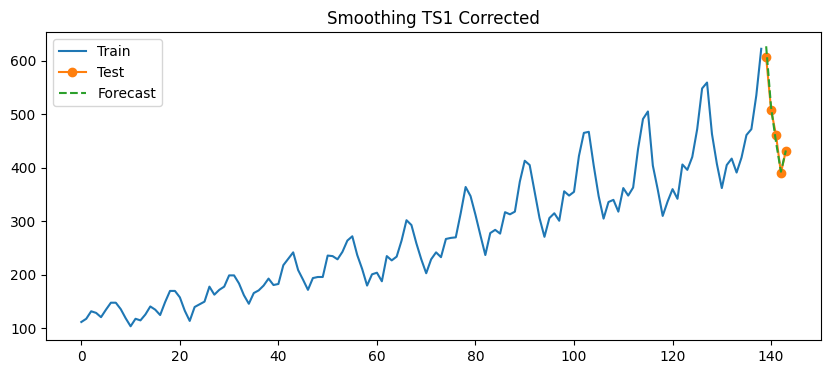

TS2 corrected MSE: 3.5812


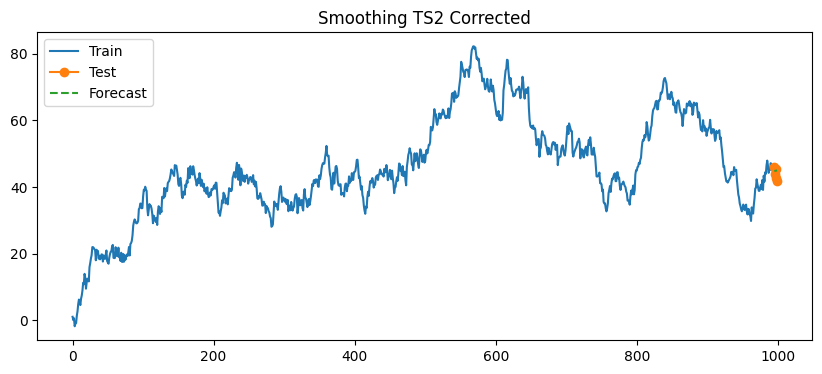

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

def process_ts_corrected(data, name, seasonal_periods=None, trend='add', seasonal='add'):
    mytime = np.arange(len(data))
    train, test = data[:-5], data[-5:]

    model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
    fit = model.fit(optimized=True)
    pred = fit.forecast(5)
    mse = mean_squared_error(test, pred)
    print(f"{name} corrected MSE: {mse:.4f}")
    plt.figure(figsize=(10, 4))
    plt.plot(mytime[:-5], train, label='Train')
    plt.plot(mytime[-5:], test, label='Test', marker='o')
    plt.plot(mytime[-5:], pred, label='Forecast', linestyle='--')
    plt.title(f"Smoothing {name} Corrected")
    plt.legend()
    plt.show()

process_ts_corrected(smoothing_ts1, "TS1", seasonal_periods=12, trend='add', seasonal='mul')

process_ts_corrected(smoothing_ts2, "TS2", seasonal_periods=None, trend='add', seasonal=None)

для ряда тс1 сезонность мультипликативная. на графике видно, что амплитуда колебаний растет вместе с трендом. 

ряда тс2 сезонность не выражена визуально. ряд похож на шум или случайное блуждание с дрейфом